# 🏏 Bangla Sports Sentiment Analysis — SVM Classifier
## Split: **70% Train / 30% Test**

| | |
|---|---|
| **Dataset** | Bangla Sports Sentiment Analysis Dataset |
| **Task** | Binary Sentiment Classification (Positive / Negative) |
| **Model** | Voting Ensemble (SVM + Logistic Regression + SGD) |
| **Split** | 70% Train — 30% Test |
| **Train Samples** | ~73,965 |
| **Test Samples** | ~8,219 |

## Cell 1 — Install & Import

In [ ]:
# !pip install scikit-learn pandas openpyxl numpy matplotlib seaborn scipy

import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import hstack

from sklearn.model_selection      import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm                  import LinearSVC
from sklearn.linear_model         import LogisticRegression, SGDClassifier
from sklearn.calibration          import CalibratedClassifierCV
from sklearn.preprocessing        import LabelEncoder
from sklearn.metrics              import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc,
    precision_recall_curve, average_precision_score
)

warnings.filterwarnings('ignore')
np.random.seed(42)

SPLIT_NAME   = '90:10'
TRAIN_SIZE   = 0.90
TEST_SIZE    = 0.10
PREFIX       = 'split9010'

plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.size': 12, 'axes.titlesize': 14,
    'figure.facecolor': 'white', 'axes.facecolor': '#F8F9FA',
    'axes.grid': True, 'grid.alpha': 0.4,
    'axes.spines.top': False, 'axes.spines.right': False,
})
COLORS = {'Positive': '#2ECC71', 'Negative': '#E74C3C',
          'primary': '#2C3E50', 'accent': '#3498DB'}

print(f'✅ Libraries loaded | Split: {SPLIT_NAME}')

✅ Libraries loaded | Split: 90:10


## Cell 2 — Load & Explore Data

📂 Loading dataset...
Shape   : (82611, 3)
Columns : ['Comment ', 'Category', 'Cleaned_Text']

Label distribution:
Category
Negative    41355
Positive    41256
Name: count, dtype: int64


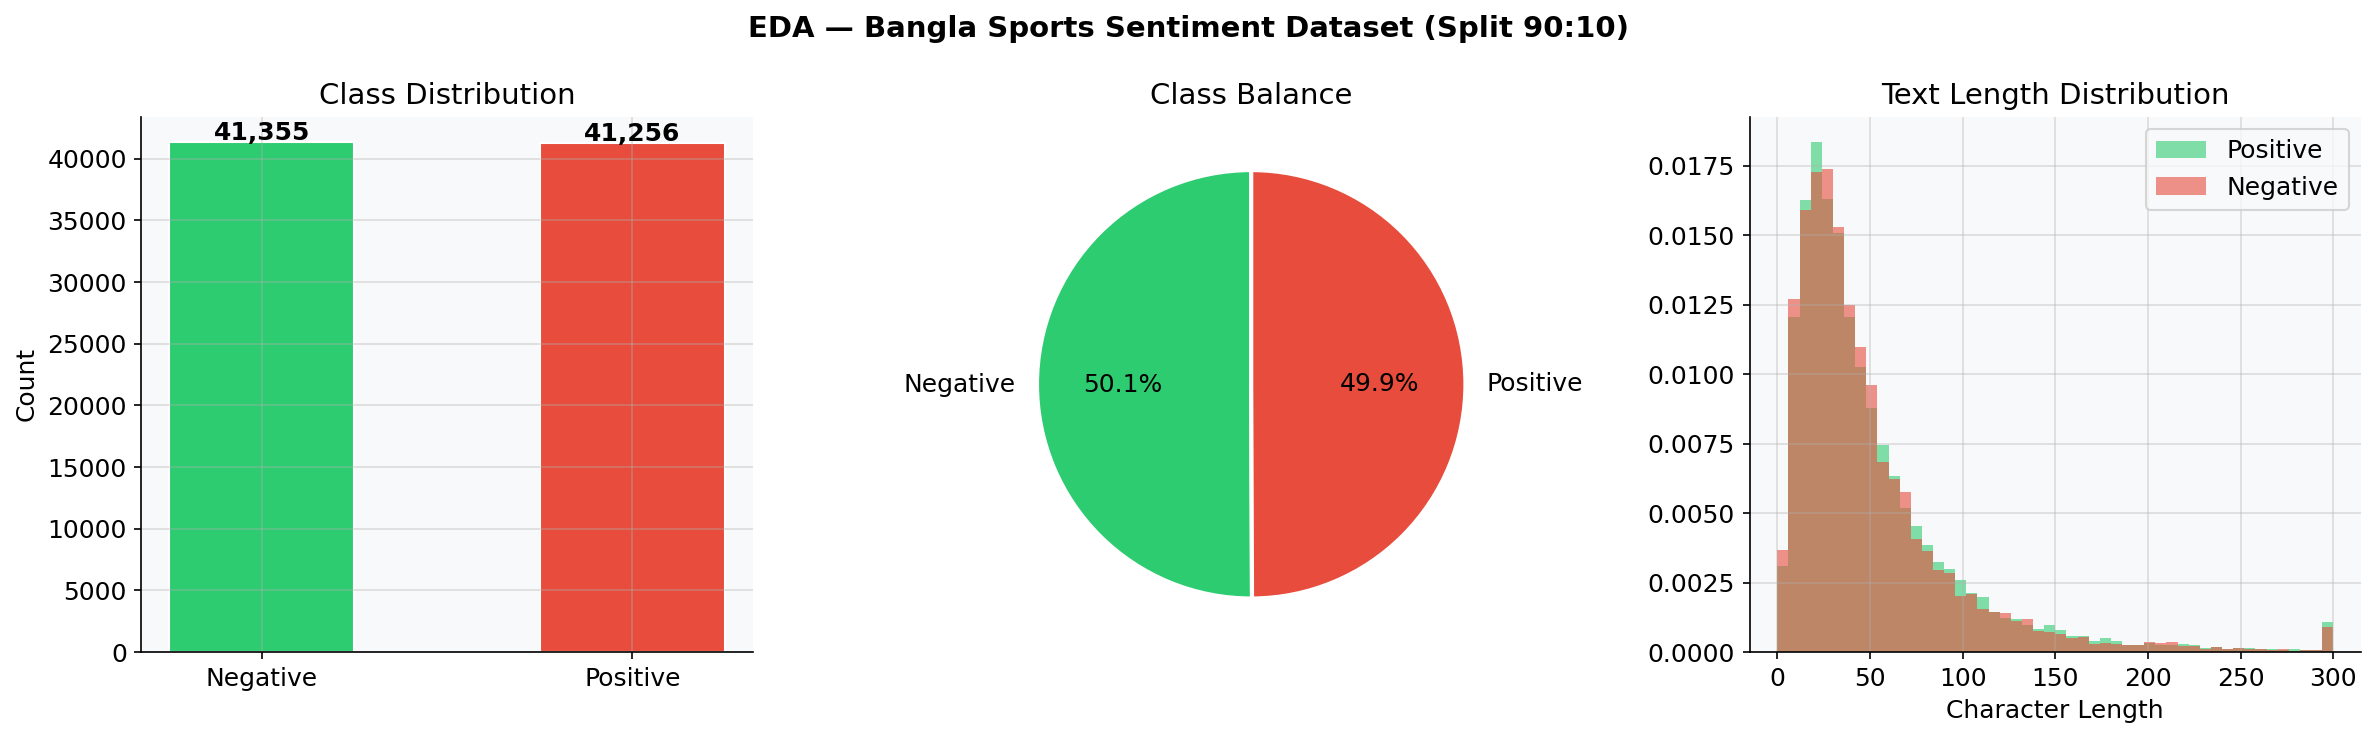

✅ EDA chart saved


In [ ]:
DATA_PATH = '/content/Bangla_Sports_Sentiment_Analysis_Dataset.xlsx'

print('📂 Loading dataset...')
df = pd.read_excel(DATA_PATH, engine='openpyxl')
df['Comment ']     = df['Comment '].fillna('')
df['Cleaned_Text'] = df['Cleaned_Text'].fillna('')

print(f'Shape   : {df.shape}')
print(f'Columns : {df.columns.tolist()}')
print(f'\nLabel distribution:\n{df["Category"].value_counts()}')

# EDA Chart
df['text_length'] = df['Comment '].str.len()
df['word_count']  = df['Comment '].str.split().str.len()
label_counts      = df['Category'].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'EDA — Bangla Sports Sentiment Dataset (Split {SPLIT_NAME})',
             fontweight='bold', fontsize=14)

# Bar chart
bars = axes[0].bar(label_counts.index, label_counts.values,
                   color=[COLORS['Positive'], COLORS['Negative']],
                   width=0.5, edgecolor='white')
for bar, cnt in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f'{cnt:,}', ha='center', fontweight='bold')
axes[0].set_title('Class Distribution'); axes[0].set_ylabel('Count')

# Pie chart
axes[1].pie(label_counts.values, labels=label_counts.index,
            colors=[COLORS['Positive'], COLORS['Negative']],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Balance')

# Text length dist
for label in ['Positive', 'Negative']:
    axes[2].hist(df[df['Category'] == label]['text_length'].clip(upper=300),
                 bins=50, alpha=0.6, color=COLORS[label], label=label, density=True)
axes[2].set_title('Text Length Distribution')
axes[2].set_xlabel('Character Length'); axes[2].legend()

plt.tight_layout()
plt.savefig(f'{PREFIX}_01_eda.png', bbox_inches='tight', dpi=300)
plt.show()
print(f'✅ EDA chart saved')

## Cell 3 — Preprocessing & Split

Split      : 90:10
Train      : 73,865 samples (90%)
Test       : 8,208  samples (10%)


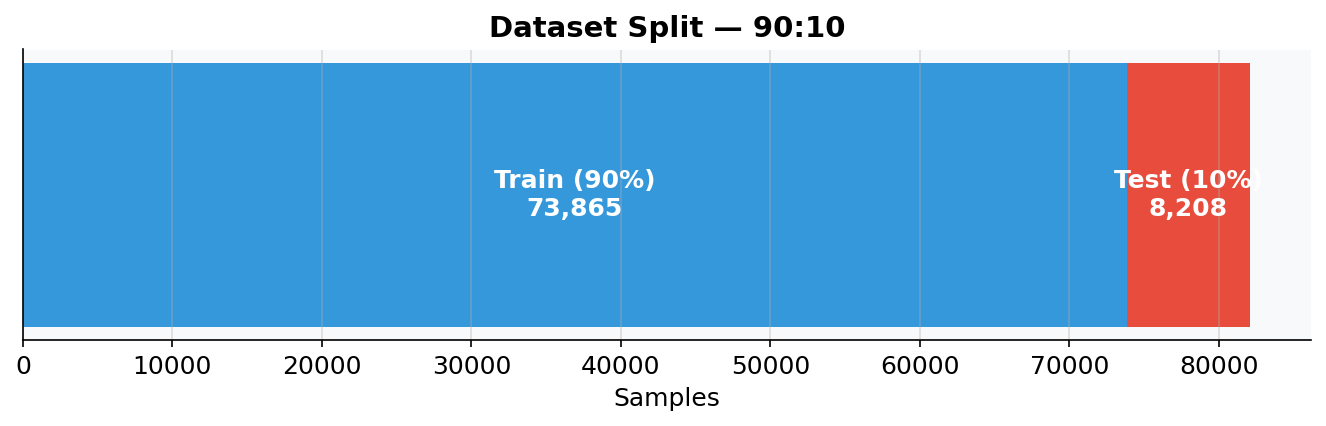

In [ ]:
def clean_bangla(text):
    if not isinstance(text, str): return ''
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'[A-Za-z0-9]', '', text)
    text = re.sub(r'[^\u0980-\u09FF\s।,!?]', ' ', text)
    text = re.sub(r'([।,!?])\1+', r'\1', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['raw_cleaned'] = df['Comment '].apply(clean_bangla)

le    = LabelEncoder()
y_all = le.fit_transform(df['Category'])
X_raw   = df['raw_cleaned']
X_clean = df['Cleaned_Text']

mask    = X_raw.str.len() > 3
X_raw   = X_raw[mask].reset_index(drop=True)
X_clean = X_clean[mask].reset_index(drop=True)
y_all   = y_all[mask]

# ── 70 / 30 Split ────────────────────────────────────────────────────────────
X_raw_train, X_raw_test, X_cl_train, X_cl_test, y_train, y_test = train_test_split(
    X_raw, X_clean, y_all,
    test_size=TEST_SIZE, random_state=42, stratify=y_all
)

print(f'Split      : {SPLIT_NAME}')
print(f'Train      : {len(X_raw_train):,} samples ({TRAIN_SIZE*100:.0f}%)')
print(f'Test       : {len(X_raw_test):,}  samples ({TEST_SIZE*100:.0f}%)')

# Split visualization
fig, ax = plt.subplots(figsize=(9, 3))
splits  = {f'Train ({TRAIN_SIZE*100:.0f}%)': len(X_raw_train),
            f'Test ({TEST_SIZE*100:.0f}%)':  len(X_raw_test)}
colors_s = ['#3498DB', '#E74C3C']
left = 0
for (name, val), color in zip(splits.items(), colors_s):
    ax.barh(0, val, left=left, color=color, height=0.5)
    ax.text(left + val/2, 0, f'{name}\n{val:,}',
            ha='center', va='center', fontweight='bold', fontsize=12, color='white')
    left += val
ax.set_yticks([]); ax.set_xlabel('Samples')
ax.set_title(f'Dataset Split — {SPLIT_NAME}', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PREFIX}_02_split.png', bbox_inches='tight', dpi=300)
plt.show()

## Cell 4 — Feature Engineering

In [ ]:
print('⚙️  Building TF-IDF features...')

V1 = TfidfVectorizer(analyzer='char_wb', ngram_range=(2,5), max_features=150000, sublinear_tf=True, min_df=2)
V2 = TfidfVectorizer(analyzer='char_wb', ngram_range=(2,5), max_features=150000, sublinear_tf=True, min_df=2)
V3 = TfidfVectorizer(analyzer='word',    ngram_range=(1,2), max_features=100000, sublinear_tf=True, min_df=2)
V4 = TfidfVectorizer(analyzer='char',    ngram_range=(3,5), max_features=100000, sublinear_tf=True, min_df=2)

X_train_feat = hstack([V1.fit_transform(X_raw_train), V2.fit_transform(X_cl_train),
                        V3.fit_transform(X_raw_train), V4.fit_transform(X_cl_train)])
X_test_feat  = hstack([V1.transform(X_raw_test),      V2.transform(X_cl_test),
                        V3.transform(X_raw_test),      V4.transform(X_cl_test)])

print(f'Total features : {X_train_feat.shape[1]:,}')
print(f'Train matrix   : {X_train_feat.shape}')
print(f'Test matrix    : {X_test_feat.shape}')
print('✅ Features ready')

⚙️  Building TF-IDF features...
Total features : 355,191
Train matrix   : (73865, 355191)
Test matrix    : (8208, 355191)
✅ Features ready


## Cell 5 — Train Models & Voting Ensemble

In [ ]:
print('🤖 Training models...')

svm_model = CalibratedClassifierCV(LinearSVC(C=3.0, max_iter=5000, random_state=42), cv=3)
lr_model  = LogisticRegression(C=3.0, max_iter=1000, solver='saga', n_jobs=-1, random_state=42)
sgd_model = SGDClassifier(loss='modified_huber', alpha=1e-5, max_iter=200, random_state=42, n_jobs=-1)

svm_model.fit(X_train_feat, y_train); print('  ✅ SVM done')
lr_model.fit(X_train_feat,  y_train); print('  ✅ LR  done')
sgd_model.fit(X_train_feat, y_train); print('  ✅ SGD done')

# Soft Voting
svm_prob  = svm_model.predict_proba(X_test_feat)
lr_prob   = lr_model.predict_proba(X_test_feat)
sgd_prob  = sgd_model.predict_proba(X_test_feat)
avg_prob  = (svm_prob + lr_prob + sgd_prob) / 3
y_pred    = np.argmax(avg_prob, axis=1)
y_prob_pos = avg_prob[:, 1]

# Metrics
test_acc  = accuracy_score(y_test, y_pred)
test_f1   = f1_score(y_test, y_pred, average='weighted')
test_prec = precision_score(y_test, y_pred, average='weighted')
test_rec  = recall_score(y_test, y_pred, average='weighted')
test_auc  = roc_auc_score(y_test, y_prob_pos)

print(f'\n══════════════════════════════════')
print(f'  Split      : {SPLIT_NAME}')
print(f'  Accuracy   : {test_acc*100:.2f}%')
print(f'  F1 Score   : {test_f1*100:.2f}%')
print(f'  Precision  : {test_prec*100:.2f}%')
print(f'  Recall     : {test_rec*100:.2f}%')
print(f'  ROC-AUC    : {test_auc*100:.2f}%')
print(f'══════════════════════════════════')
print(classification_report(y_test, y_pred, target_names=le.classes_))

🤖 Training models...
  ✅ SVM done
  ✅ LR  done
  ✅ SGD done

══════════════════════════════════
  Split      : 90:10
  Accuracy   : 82.94%
  F1 Score   : 82.94%
  Precision  : 82.95%
  Recall     : 82.94%
  ROC-AUC    : 89.96%
══════════════════════════════════
              precision    recall  f1-score   support

    Negative       0.84      0.82      0.83      4105
    Positive       0.82      0.84      0.83      4103

    accuracy                           0.83      8208
   macro avg       0.83      0.83      0.83      8208
weighted avg       0.83      0.83      0.83      8208



## Cell 6 — Confusion Matrix

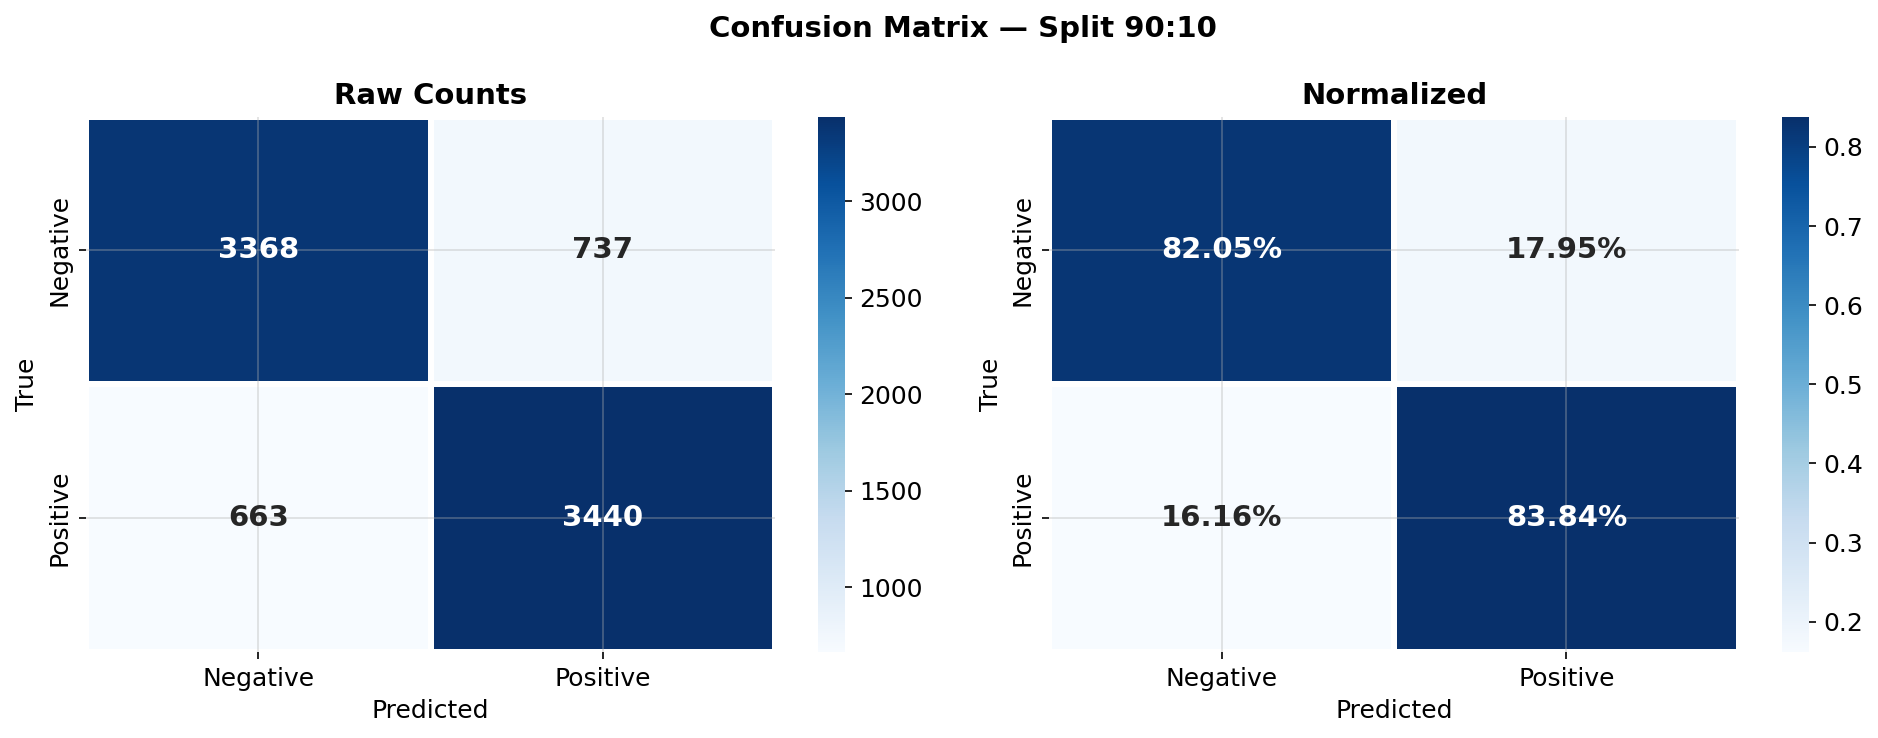

✅ Confusion matrix saved


In [ ]:
cm      = confusion_matrix(y_test, y_pred)
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'Confusion Matrix — Split {SPLIT_NAME}', fontweight='bold', fontsize=14)

for ax, data, fmt, title in zip(axes, [cm, cm_norm], ['d', '.2%'],
                                 ['Raw Counts', 'Normalized']):
    sns.heatmap(data, annot=True, fmt=fmt,
                xticklabels=le.classes_, yticklabels=le.classes_,
                cmap='Blues', ax=ax, linewidths=2, linecolor='white',
                annot_kws={'size': 14, 'weight': 'bold'})
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.tight_layout()
plt.savefig(f'{PREFIX}_03_confusion_matrix.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ Confusion matrix saved')

## Cell 7 — ROC & Precision-Recall Curve

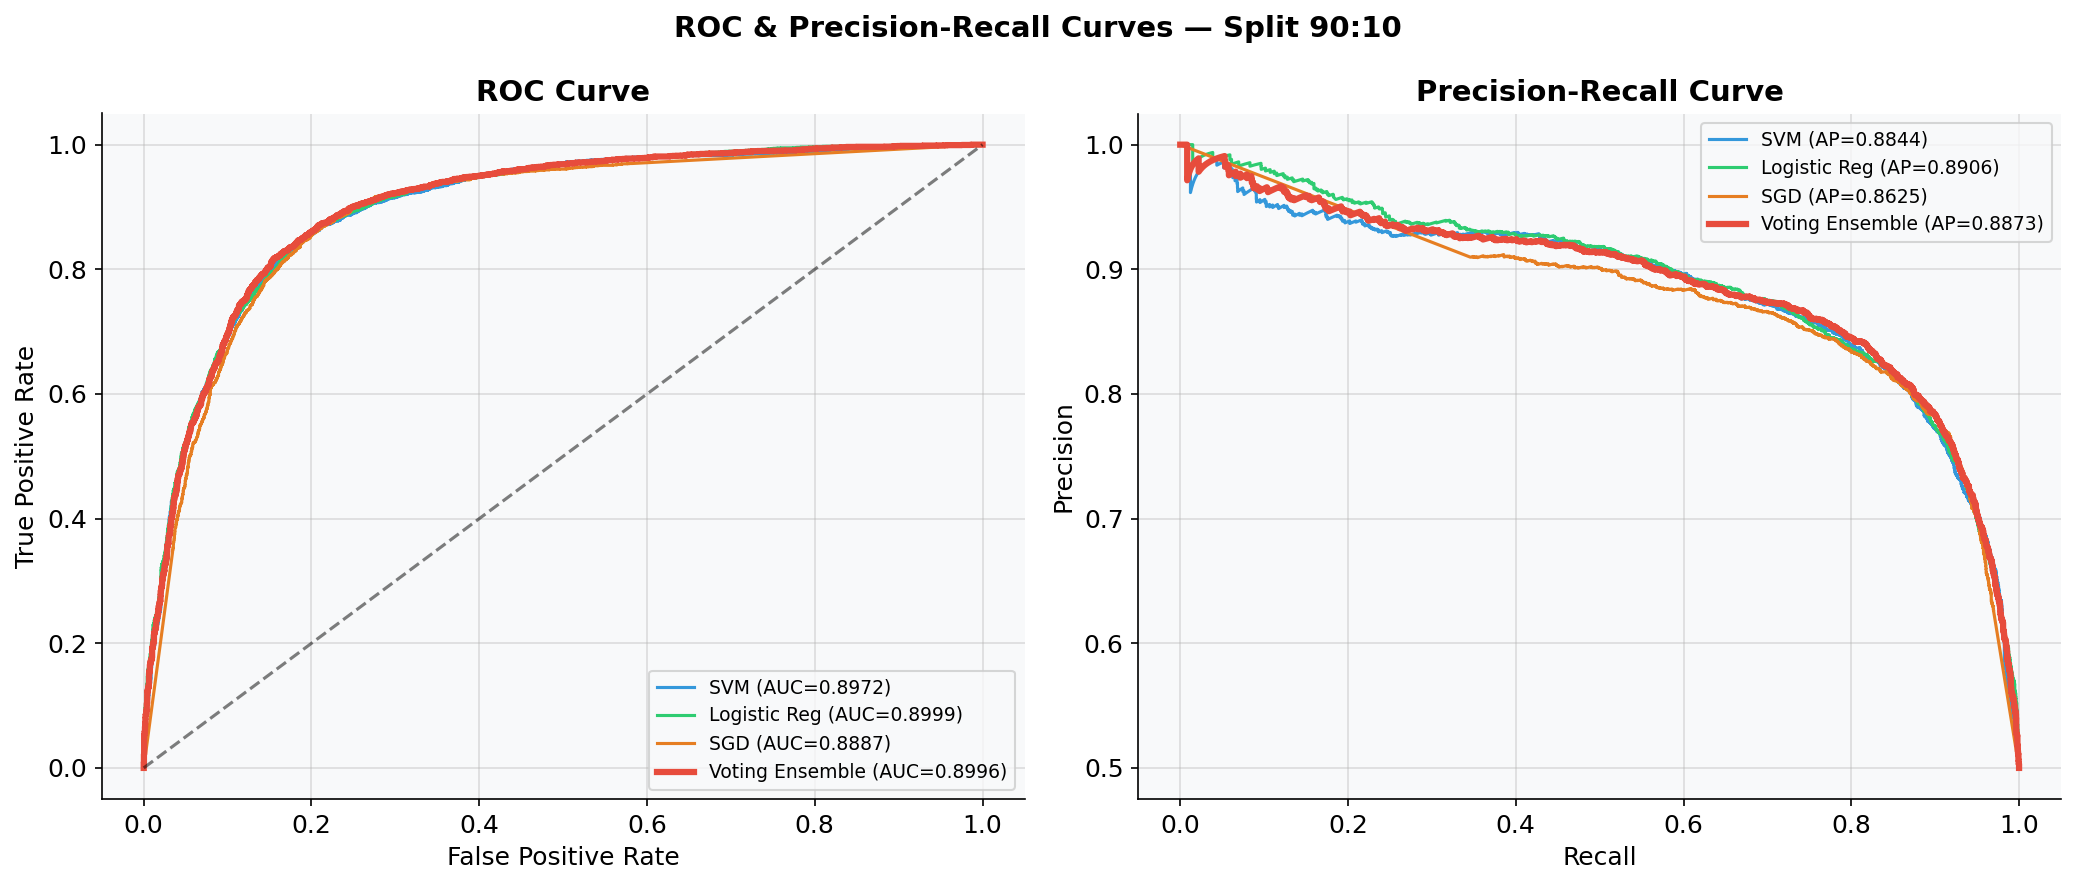

✅ ROC & PR curves saved


In [ ]:
models_prob = {
    'SVM':             svm_prob[:, 1],
    'Logistic Reg':    lr_prob[:, 1],
    'SGD':             sgd_prob[:, 1],
    'Voting Ensemble': y_prob_pos,
}
curve_colors = ['#3498DB', '#2ECC71', '#E67E22', '#E74C3C']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(f'ROC & Precision-Recall Curves — Split {SPLIT_NAME}',
             fontweight='bold', fontsize=14)

ax = axes[0]
for (name, prob), color in zip(models_prob.items(), curve_colors):
    fpr, tpr, _ = roc_curve(y_test, prob)
    lw = 3 if name == 'Voting Ensemble' else 1.5
    ax.plot(fpr, tpr, color=color, lw=lw, label=f'{name} (AUC={auc(fpr,tpr):.4f})')
ax.plot([0,1],[0,1],'k--', lw=1.5, alpha=0.5)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve', fontweight='bold'); ax.legend(loc='lower right', fontsize=9)

ax = axes[1]
for (name, prob), color in zip(models_prob.items(), curve_colors):
    prec_c, rec_c, _ = precision_recall_curve(y_test, prob)
    ap = average_precision_score(y_test, prob)
    lw = 3 if name == 'Voting Ensemble' else 1.5
    ax.plot(rec_c, prec_c, color=color, lw=lw, label=f'{name} (AP={ap:.4f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve', fontweight='bold'); ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{PREFIX}_04_roc_pr.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ ROC & PR curves saved')

## Cell 8 — Cross Validation

🔁 Running 5-Fold Cross-Validation...
CV Accuracy : 0.7970 ± 0.0032
CV F1 Score : 0.7970 ± 0.0032


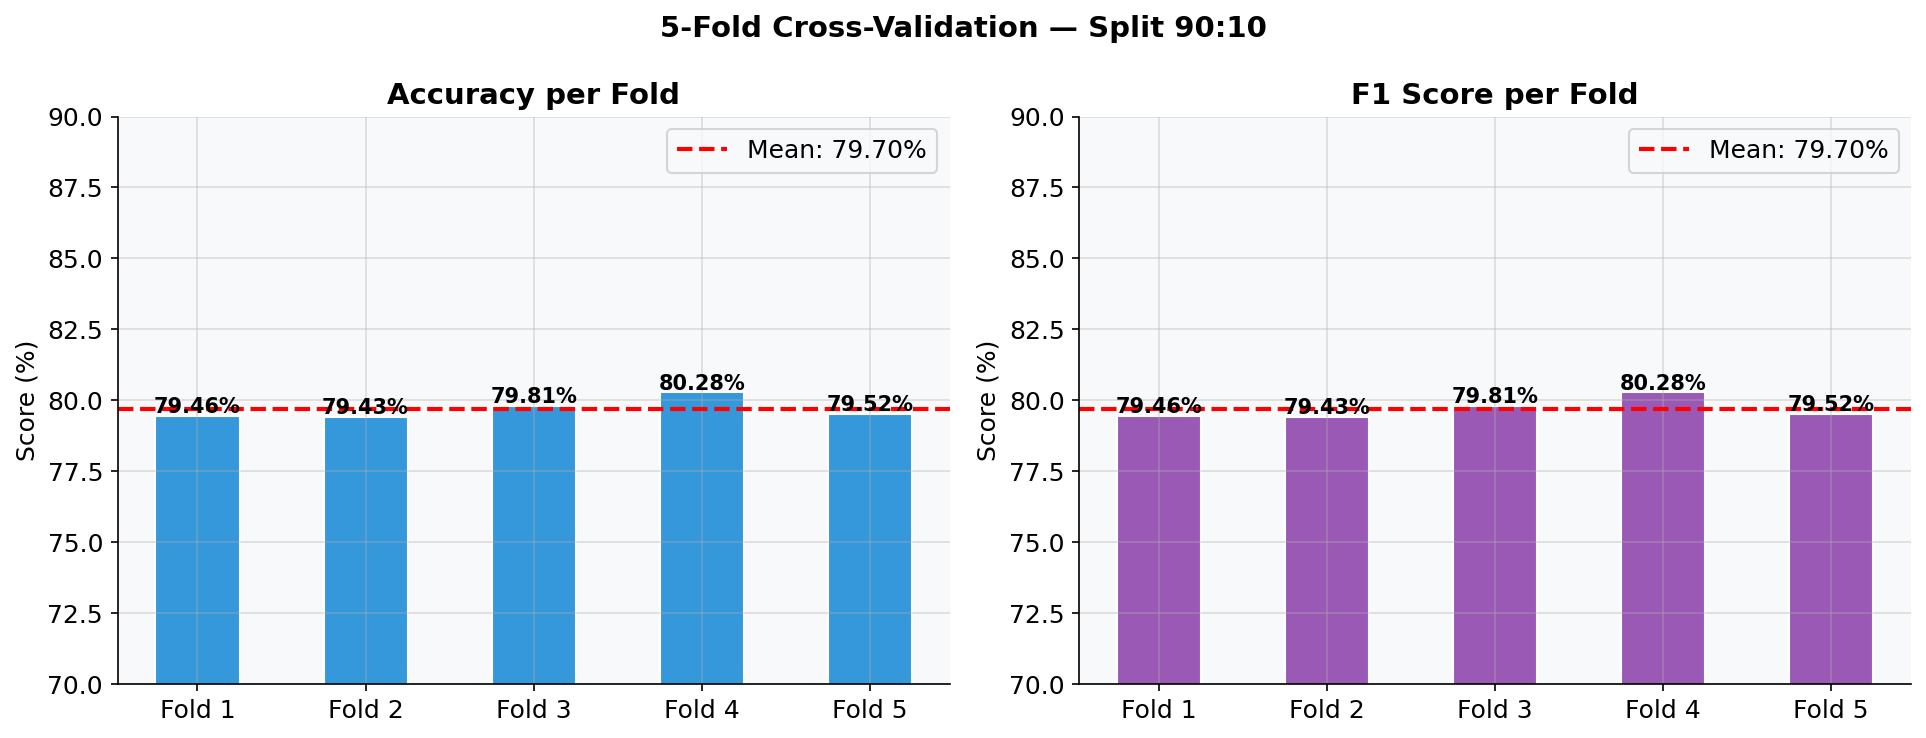

✅ Cross-validation chart saved


In [ ]:
from sklearn.pipeline import Pipeline
print('🔁 Running 5-Fold Cross-Validation...')

cv_pipe = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(2,5),
                               max_features=150000, sublinear_tf=True, min_df=2)),
    ('clf',   LogisticRegression(C=3.0, max_iter=1000, solver='saga',
                                  n_jobs=-1, random_state=42))
])

skf    = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_acc = cross_val_score(cv_pipe, X_raw_train, y_train, cv=skf, scoring='accuracy', n_jobs=-1)
cv_f1  = cross_val_score(cv_pipe, X_raw_train, y_train, cv=skf, scoring='f1_weighted', n_jobs=-1)

print(f'CV Accuracy : {cv_acc.mean():.4f} ± {cv_acc.std():.4f}')
print(f'CV F1 Score : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(f'5-Fold Cross-Validation — Split {SPLIT_NAME}', fontweight='bold', fontsize=14)
fold_labels = [f'Fold {i+1}' for i in range(5)]

for ax, scores, title, color in zip(
    axes, [cv_acc, cv_f1],
    ['Accuracy per Fold', 'F1 Score per Fold'],
    ['#3498DB', '#9B59B6']
):
    bars = ax.bar(fold_labels, scores*100, color=color, width=0.5, edgecolor='white')
    for bar, val in zip(bars, scores):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                f'{val*100:.2f}%', ha='center', fontweight='bold', fontsize=10)
    ax.axhline(y=scores.mean()*100, color='red', linestyle='--', lw=2,
               label=f'Mean: {scores.mean()*100:.2f}%')
    ax.set_ylim(70, 90); ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Score (%)'); ax.legend()

plt.tight_layout()
plt.savefig(f'{PREFIX}_05_cross_val.png', bbox_inches='tight', dpi=300)
plt.show()
print('✅ Cross-validation chart saved')

## Cell 9 — Final Summary

In [ ]:
print('=' * 50)
print(f'  FINAL RESULTS — Split {SPLIT_NAME}')
print('=' * 50)
print(f'  Train Samples : {len(X_raw_train):,}')
print(f'  Test Samples  : {len(X_raw_test):,}')
print(f'  Accuracy      : {test_acc*100:.2f}%')
print(f'  F1 Score      : {test_f1*100:.2f}%')
print(f'  Precision     : {test_prec*100:.2f}%')
print(f'  Recall        : {test_rec*100:.2f}%')
print(f'  ROC-AUC       : {test_auc*100:.2f}%')
print(f'  CV Accuracy   : {cv_acc.mean()*100:.2f}% ± {cv_acc.std()*100:.2f}%')
print('=' * 50)
print('\nSaved charts:')
for f in [f'{PREFIX}_01_eda.png', f'{PREFIX}_02_split.png',
           f'{PREFIX}_03_confusion_matrix.png', f'{PREFIX}_04_roc_pr.png',
           f'{PREFIX}_05_cross_val.png']:
    print(f'  ✅ {f}')

  FINAL RESULTS — Split 90:10
  Train Samples : 73,865
  Test Samples  : 8,208
  Accuracy      : 82.94%
  F1 Score      : 82.94%
  Precision     : 82.95%
  Recall        : 82.94%
  ROC-AUC       : 89.96%
  CV Accuracy   : 79.70% ± 0.32%

Saved charts:
  ✅ split9010_01_eda.png
  ✅ split9010_02_split.png
  ✅ split9010_03_confusion_matrix.png
  ✅ split9010_04_roc_pr.png
  ✅ split9010_05_cross_val.png
